#### Install + Load Dataset

In [1]:
!pip install kaggle

In [28]:
!kaggle datasets download -d omkargurav/face-mask-dataset


Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [29]:
from zipfile import ZipFile
file = "face-mask-dataset.zip"

with ZipFile(file, 'r') as zip:
    zip.extractall()
    print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


#### Load & Preprocess Images

In [30]:
import os
import numpy as np
from PIL import Image

In [31]:
with_mask_path = "data/with_mask/"
without_mask_path = "data/without_mask/"

In [32]:
data = []
labels = []

In [33]:

# label: mask = 0, no mask = 1

for img in os.listdir(with_mask_path):
    if img.endswith(("jpg","png")):
        image = Image.open(with_mask_path + img)

        # Fix transparency warning (important)
        if image.mode in ("RGBA", "P"):
            image = image.convert("RGB")

        image = image.resize((128,128))
        data.append(np.array(image))
        labels.append(0)

for img in os.listdir(without_mask_path):
    if img.endswith(("jpg","png")):
        image = Image.open(without_mask_path + img)

        # Fix transparency warning (important)
        if image.mode in ("RGBA", "P"):
            image = image.convert("RGB")

        image = image.resize((128,128))
        data.append(np.array(image))
        labels.append(1)

print("Images Loaded:", len(data))

Images Loaded: 7553


#### Train-Test Split & Normalization

In [34]:
from sklearn.model_selection import train_test_split


In [35]:
X = np.array(data) / 255.0   # normalization
Y = np.array(labels)

In [43]:
# First: Train + Test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Second: Train + Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (5437, 128, 128, 3) Val: (605, 128, 128, 3) Test: (1511, 128, 128, 3)


#### Image Augmentation + MobileNetV2 Model

In [44]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [45]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

In [46]:
datagen.fit(X_train)

In [47]:
base_model = MobileNetV2(input_shape=(128,128,3), include_top=False, weights="imagenet")
base_model.trainable = False

In [48]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Binary output
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       5,243,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,501,377 (28.62 MB)

 Trainable params: 5,243,393 (20.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Train Model

In [49]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10
)


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 94s 488ms/step - accuracy: 0.9417 - loss: 0.3253 - val_accuracy: 0.9884 - val_loss: 0.0420
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 81s 474ms/step - accuracy: 0.9658 - loss: 0.0968 - val_accuracy: 0.9851 - val_loss: 0.0532
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 85s 490ms/step - accuracy: 0.9717 - loss: 0.0828 - val_accuracy: 0.9802 - val_loss: 0.0395
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 79s 464ms/step - accuracy: 0.9755 - loss: 0.0748 - val_accuracy: 0.9752 - val_loss: 0.0551
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 77s 453ms/step - accuracy: 0.9781 - loss: 0.0649 - val_accuracy: 0.9901 - val_loss: 0.0316
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 78s 457ms/step - accuracy: 0.9785 - loss: 0.0626 - val_accuracy: 0.9835 - val_loss: 0.0430
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 77s 451ms/step - accuracy: 0.9781 - loss: 0.0653 - val_accuracy: 0.9818 - val_loss: 0.0428
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 77s 451ms/step - accuracy: 0.9781 - loss: 0

#### Evaluate Model

In [50]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.9868 - loss: 0.0362
Test Accuracy: 0.9867637157440186


#### Confusion Matrix & Report

In [51]:
from sklearn.metrics import classification_report, confusion_matrix


In [52]:

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 327ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       761
           1       0.98      0.99      0.99       750

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511


Confusion Matrix:

[[749  12]
 [  8 742]]


#### Prediction on New Image

In [55]:
import cv2
import matplotlib.pyplot as plt


Enter full image path:  test1.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Prediction: Mask


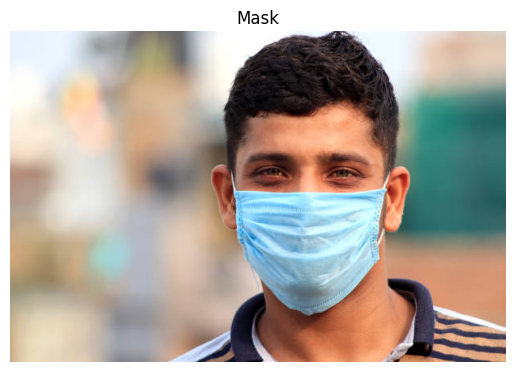

In [59]:

def predict_image(path):
    img = cv2.imread(path)

    # Check if image is loaded
    if img is None:
        print("❌ Error: Image not found or unreadable. Check file path.")
        return

    img_resized = cv2.resize(img, (128,128)) / 255.0
    img_reshaped = img_resized.reshape(1,128,128,3)

    prediction = model.predict(img_reshaped)[0][0]

    label = "Mask" if prediction < 0.5 else "No Mask"

    print("Prediction:", label)

    # Show image (converting BGR → RGB for display)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()


# Run prediction
predict_image(input("Enter full image path: "))


Enter full image path:  test2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Prediction: No Mask


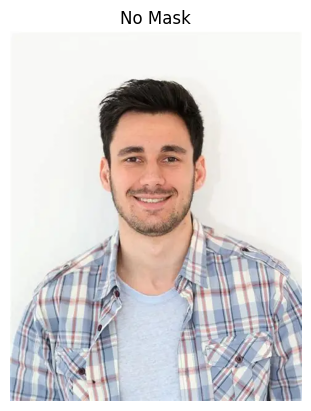

In [64]:

def predict_image(path):
    img = cv2.imread(path)

    # Check if image is loaded
    if img is None:
        print("❌ Error: Image not found or unreadable. Check file path.")
        return

    img_resized = cv2.resize(img, (128,128)) / 255.0
    img_reshaped = img_resized.reshape(1,128,128,3)

    prediction = model.predict(img_reshaped)[0][0]

    label = "Mask" if prediction < 0.5 else "No Mask"

    print("Prediction:", label)

    # Show image (converting BGR → RGB for display)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()


# Run prediction
predict_image(input("Enter full image path: "))


Enter full image path:  test4.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Prediction: Mask


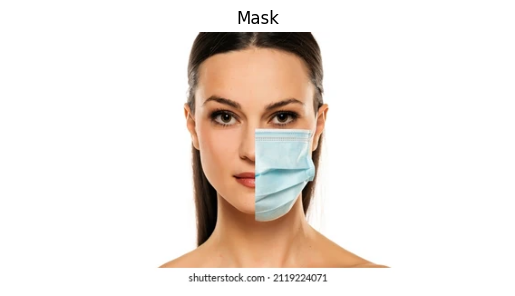

In [67]:

def predict_image(path):
    img = cv2.imread(path)

    # Check if image is loaded
    if img is None:
        print("❌ Error: Image not found or unreadable. Check file path.")
        return

    img_resized = cv2.resize(img, (128,128)) / 255.0
    img_reshaped = img_resized.reshape(1,128,128,3)

    prediction = model.predict(img_reshaped)[0][0]

    label = "Mask" if prediction < 0.5 else "No Mask"

    print("Prediction:", label)

    # Show image (converting BGR → RGB for display)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()


# Run prediction
predict_image(input("Enter full image path: "))


Enter full image path:  test5.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Prediction: No Mask


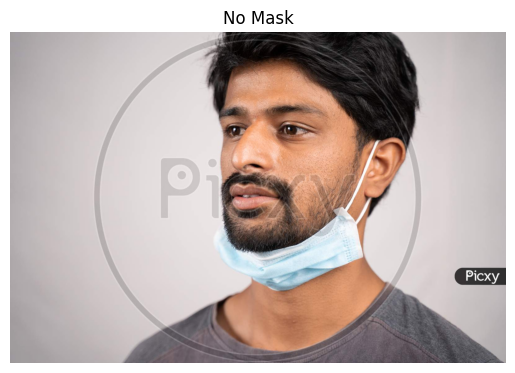

In [68]:

def predict_image(path):
    img = cv2.imread(path)

    # Check if image is loaded
    if img is None:
        print("❌ Error: Image not found or unreadable. Check file path.")
        return

    img_resized = cv2.resize(img, (128,128)) / 255.0
    img_reshaped = img_resized.reshape(1,128,128,3)

    prediction = model.predict(img_reshaped)[0][0]

    label = "Mask" if prediction < 0.5 else "No Mask"

    print("Prediction:", label)

    # Show image (converting BGR → RGB for display)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()


# Run prediction
predict_image(input("Enter full image path: "))


In [70]:
model.save("face_mask_model.h5")
print("Model Saved Successfully!")


Model Saved Successfully!
